In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import shap

from sklearn.model_selection import train_test_split

c:\Users\Huawei\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv("../data/processed/german_credit_clean.csv")

df.head()

,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate,personal_status_sex,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,target_binary
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,67,A143,A152,2,A173,1,A192,A201,1,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,22,A143,A152,1,A173,1,A191,A201,2,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,49,A143,A152,1,A172,2,A191,A201,1,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,45,A143,A153,1,A173,2,A191,A201,1,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,53,A143,A153,2,A173,2,A191,A201,2,1


In [5]:
target = "target_binary"

numeric_features = [
    "duration_months",
    "credit_amount",
    "installment_rate",
    "residence_since",
    "age",
    "existing_credits",
    "num_dependents"
]

categorical_features = [
    "checking_status",
    "credit_history",
    "purpose",
    "savings_status",
    "employment_since",
    "personal_status_sex",
    "other_debtors",
    "property",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker"
]

X = df[numeric_features + categorical_features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 20)
y shape: (1000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800, 20)
Testing set: (200, 20)


In [7]:
models_path = Path("../outputs/models")

log_reg_model = joblib.load(models_path / "logistic_regression.joblib")
rf_model = joblib.load(models_path / "random_forest.joblib")

print("Models loaded successfully.")

Models loaded successfully.


In [8]:
log_reg_preprocessor = log_reg_model.named_steps["preprocessor"]
log_reg_classifier = log_reg_model.named_steps["classifier"]

feature_names = log_reg_preprocessor.get_feature_names_out()

coefficients = log_reg_classifier.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df_sorted = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

coef_df_sorted.head(15)

,Feature,Coefficient,Abs_Coefficient
10,cat__checking_status_A14,-0.987410,0.987410
23,cat__purpose_A46,0.958526,0.958526
17,cat__purpose_A41,-0.887080,0.887080
15,cat__credit_history_A34,-0.852003,0.852003
29,cat__savings_status_A64,-0.676792,0.676792
60,cat__foreign_worker_A202,-0.651421,0.651421
46,cat__property_A124,0.635350,0.635350
7,cat__checking_status_A11,0.620797,0.620797
34,cat__employment_since_A74,-0.595362,0.595362
11,cat__credit_history_A30,0.589948,0.589948


In [9]:
tables_path = Path("../outputs/tables")
tables_path.mkdir(parents=True, exist_ok=True)

coef_df_sorted.to_csv(tables_path / "logistic_regression_coefficients.csv", index=False)

print("Saved Logistic Regression coefficients.")

Saved Logistic Regression coefficients.


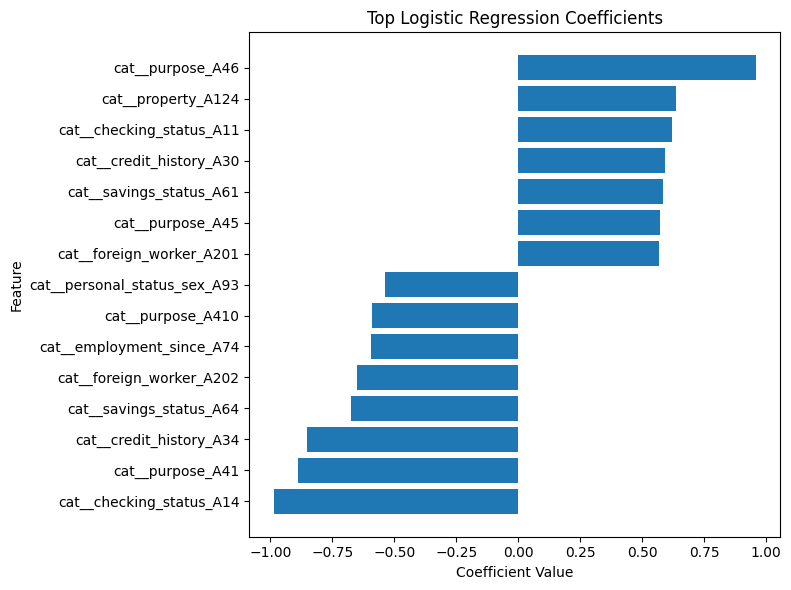

In [10]:
top_coef = coef_df_sorted.head(15).sort_values(by="Coefficient")

plt.figure(figsize=(8, 6))
plt.barh(top_coef["Feature"], top_coef["Coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()

figures_path = Path("../outputs/figures")
figures_path.mkdir(parents=True, exist_ok=True)

plt.savefig(figures_path / "logistic_regression_top_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

rf_feature_names = rf_preprocessor.get_feature_names_out()
rf_importances = rf_classifier.feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
})

rf_importance_df = rf_importance_df.sort_values(by="Importance", ascending=False)

rf_importance_df.head(15)

,Feature,Importance
10,cat__checking_status_A14,0.099817
1,num__credit_amount,0.081871
0,num__duration_months,0.080657
4,num__age,0.060652
7,cat__checking_status_A11,0.046047
15,cat__credit_history_A34,0.031766
2,num__installment_rate,0.028853
26,cat__savings_status_A61,0.027694
49,cat__other_installment_plans_A143,0.022093
8,cat__checking_status_A12,0.022021


In [12]:
rf_importance_df.to_csv(tables_path / "random_forest_feature_importance.csv", index=False)

print("Saved Random Forest feature importance.")

Saved Random Forest feature importance.


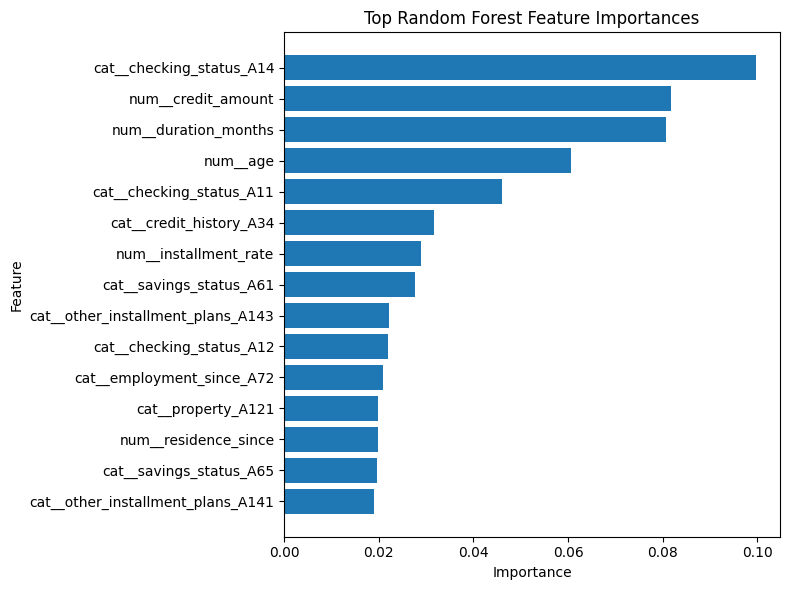

In [13]:
top_rf_importance = rf_importance_df.head(15).sort_values(by="Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_rf_importance["Feature"], top_rf_importance["Importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(figures_path / "random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
X_test_transformed = rf_preprocessor.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=rf_feature_names
)

X_test_transformed_df.head()

,num__duration_months,num__credit_amount,num__installment_rate,num__residence_since,num__age,num__existing_credits,num__num_dependents,cat__checking_status_A11,cat__checking_status_A12,cat__checking_status_A13,...,cat__housing_A152,cat__housing_A153,cat__job_A171,cat__job_A172,cat__job_A173,cat__job_A174,cat__telephone_A191,cat__telephone_A192,cat__foreign_worker_A201,cat__foreign_worker_A202
0,-0.234548,-0.477788,0.052281,0.153060,0.061263,-0.718745,-0.436436,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,-0.742595,-0.497625,0.942164,-0.747293,-0.119922,1.045047,-0.436436,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,0.273499,-0.810513,0.942164,1.053413,1.148377,-0.718745,-0.436436,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,-0.234548,-0.032034,0.052281,-1.647646,-0.391701,-0.718745,-0.436436,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,0.527522,-0.250607,0.942164,-0.747293,-1.116443,1.045047,-0.436436,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [15]:
explainer = shap.TreeExplainer(rf_classifier)

raw_shap_values = explainer.shap_values(X_test_transformed_df)

if isinstance(raw_shap_values, list):
    shap_values_bad = raw_shap_values[1]
elif len(np.array(raw_shap_values).shape) == 3:
    shap_values_bad = raw_shap_values[:, :, 1]
else:
    shap_values_bad = raw_shap_values

print("SHAP values shape:", shap_values_bad.shape)

SHAP values shape: (200, 61)


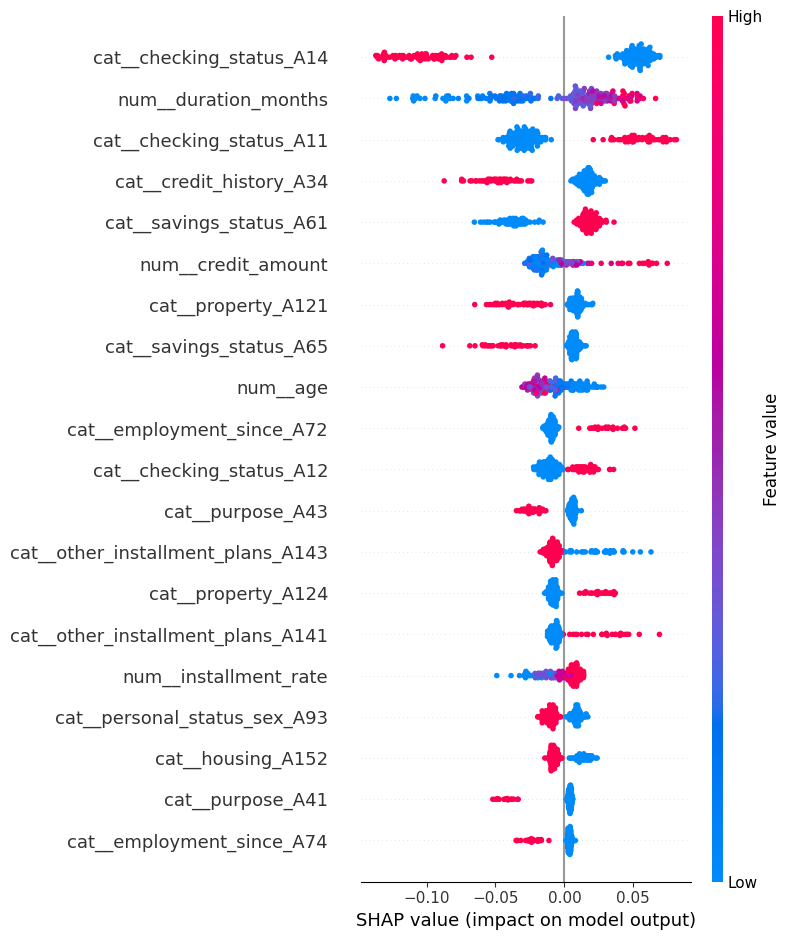

In [16]:
shap.summary_plot(
    shap_values_bad,
    X_test_transformed_df,
    show=False
)

plt.tight_layout()
plt.savefig(figures_path / "shap_summary_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

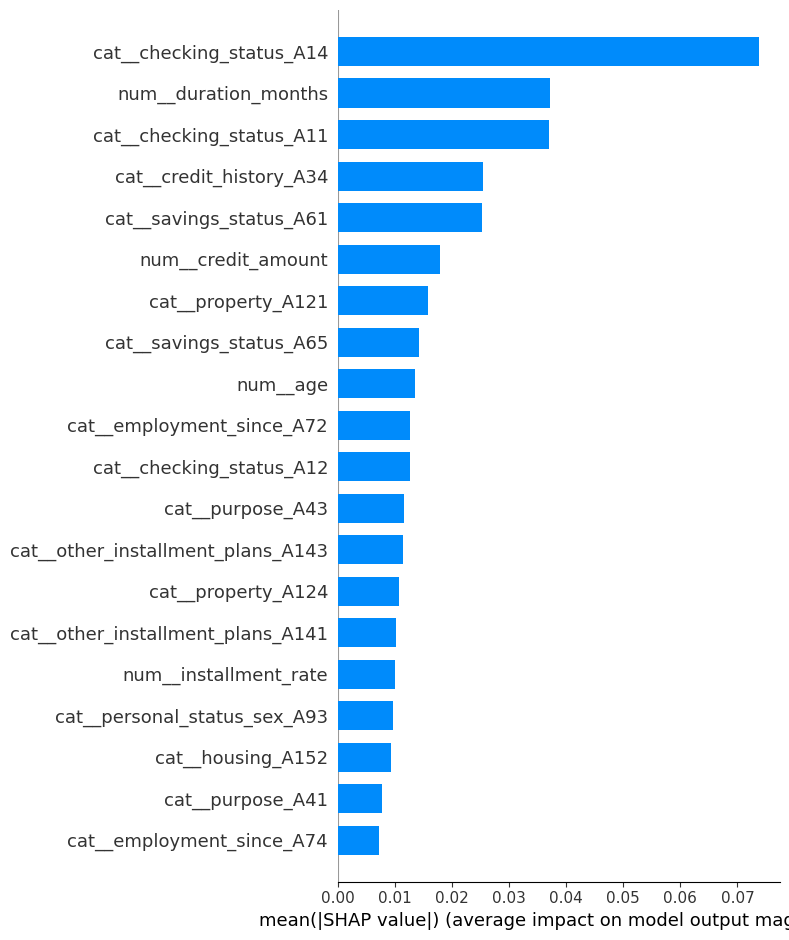

In [17]:
shap.summary_plot(
    shap_values_bad,
    X_test_transformed_df,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(figures_path / "shap_bar_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

highest_risk_index = int(np.argmax(rf_probabilities))
lowest_risk_index = int(np.argmin(rf_probabilities))

print("Highest-risk applicant position:", highest_risk_index)
print("Highest-risk probability:", rf_probabilities[highest_risk_index])

print("Lowest-risk applicant position:", lowest_risk_index)
print("Lowest-risk probability:", rf_probabilities[lowest_risk_index])

Highest-risk applicant position: 195
Highest-risk probability: 0.8172345198204072
Lowest-risk applicant position: 12
Lowest-risk probability: 0.05043231307759701


In [19]:
highest_risk_applicant = X_test.iloc[[highest_risk_index]].copy()
highest_risk_applicant["Predicted_Bad_Risk_Probability"] = rf_probabilities[highest_risk_index]
highest_risk_applicant["Actual_Target"] = y_test.iloc[highest_risk_index]

highest_risk_applicant


,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,checking_status,credit_history,purpose,...,personal_status_sex,other_debtors,property,other_installment_plans,housing,job,telephone,foreign_worker,Predicted_Bad_Risk_Probability,Actual_Target
522,48,7119,3,4,53,2,2,A11,A30,A42,...,A93,A101,A124,A143,A153,A173,A191,A201,0.817235,1


In [20]:
lowest_risk_applicant = X_test.iloc[[lowest_risk_index]].copy()
lowest_risk_applicant["Predicted_Bad_Risk_Probability"] = rf_probabilities[lowest_risk_index]
lowest_risk_applicant["Actual_Target"] = y_test.iloc[lowest_risk_index]

lowest_risk_applicant

,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,checking_status,credit_history,purpose,...,personal_status_sex,other_debtors,property,other_installment_plans,housing,job,telephone,foreign_worker,Predicted_Bad_Risk_Probability,Actual_Target
234,4,1544,2,1,42,3,2,A14,A34,A43,...,A93,A101,A121,A143,A152,A172,A191,A201,0.050432,0


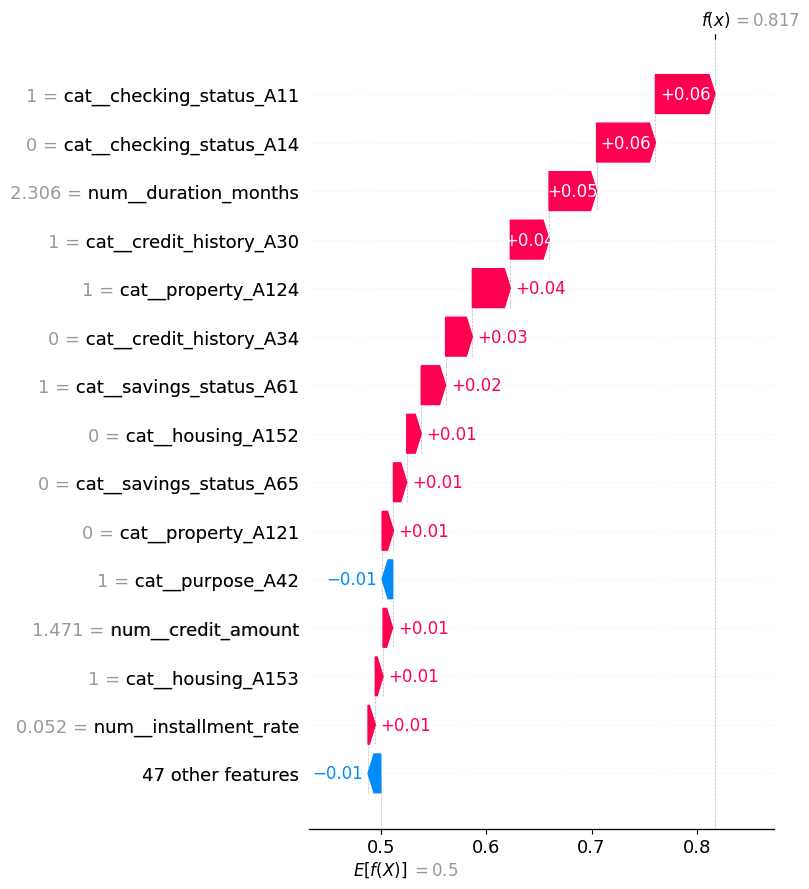

In [21]:
expected_value = explainer.expected_value

if isinstance(expected_value, list):
    base_value_bad = expected_value[1]
elif isinstance(expected_value, np.ndarray):
    base_value_bad = expected_value[1] if expected_value.shape[0] > 1 else expected_value[0]
else:
    base_value_bad = expected_value

highest_explanation = shap.Explanation(
    values=shap_values_bad[highest_risk_index],
    base_values=base_value_bad,
    data=X_test_transformed_df.iloc[highest_risk_index],
    feature_names=rf_feature_names
)

shap.plots.waterfall(highest_explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig(figures_path / "shap_waterfall_highest_risk_applicant.png", dpi=300, bbox_inches="tight")
plt.show()


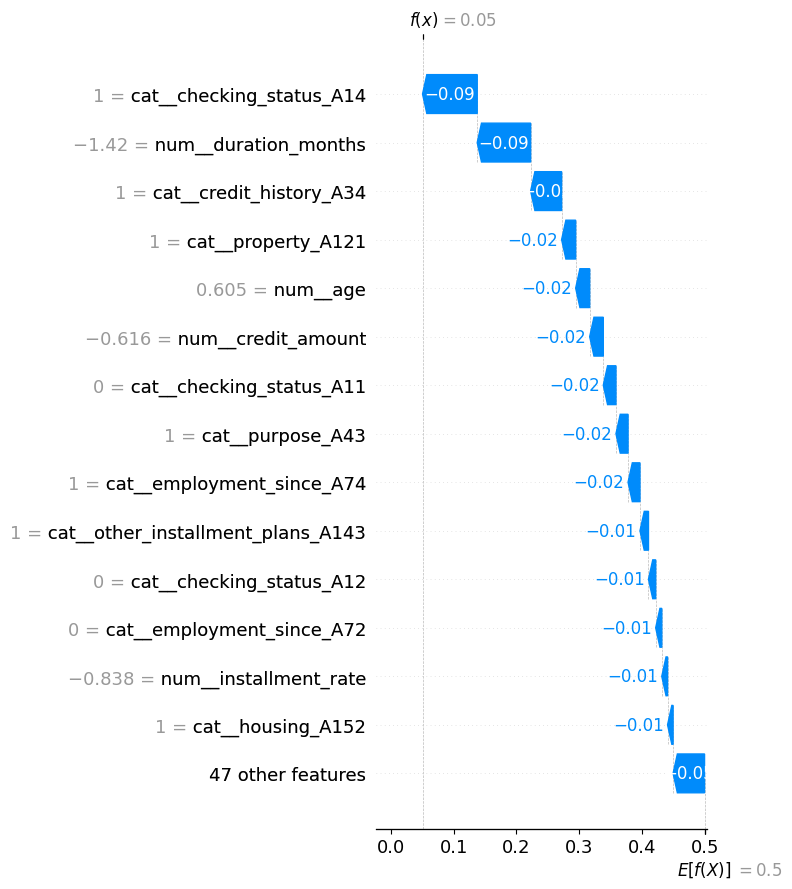

In [22]:
lowest_explanation = shap.Explanation(
    values=shap_values_bad[lowest_risk_index],
    base_values=base_value_bad,
    data=X_test_transformed_df.iloc[lowest_risk_index],
    feature_names=rf_feature_names
)

shap.plots.waterfall(lowest_explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig(figures_path / "shap_waterfall_lowest_risk_applicant.png", dpi=300, bbox_inches="tight")
plt.show()


In [23]:
local_examples = pd.concat([
    highest_risk_applicant.assign(Example="Highest Risk"),
    lowest_risk_applicant.assign(Example="Lowest Risk")
])

local_examples.to_csv(tables_path / "local_explanation_examples.csv", index=False)

print("Saved local explanation examples.")
local_examples

Saved local explanation examples.


,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,checking_status,credit_history,purpose,...,other_debtors,property,other_installment_plans,housing,job,telephone,foreign_worker,Predicted_Bad_Risk_Probability,Actual_Target,Example
522,48,7119,3,4,53,2,2,A11,A30,A42,...,A101,A124,A143,A153,A173,A191,A201,0.817235,1,Highest Risk
234,4,1544,2,1,42,3,2,A14,A34,A43,...,A101,A121,A143,A152,A172,A191,A201,0.050432,0,Lowest Risk


In [24]:
coef_df_sorted.head(10)

,Feature,Coefficient,Abs_Coefficient
10,cat__checking_status_A14,-0.987410,0.987410
23,cat__purpose_A46,0.958526,0.958526
17,cat__purpose_A41,-0.887080,0.887080
15,cat__credit_history_A34,-0.852003,0.852003
29,cat__savings_status_A64,-0.676792,0.676792
60,cat__foreign_worker_A202,-0.651421,0.651421
46,cat__property_A124,0.635350,0.635350
7,cat__checking_status_A11,0.620797,0.620797
34,cat__employment_since_A74,-0.595362,0.595362
11,cat__credit_history_A30,0.589948,0.589948


In [25]:
rf_importance_df.head(10)

,Feature,Importance
10,cat__checking_status_A14,0.099817
1,num__credit_amount,0.081871
0,num__duration_months,0.080657
4,num__age,0.060652
7,cat__checking_status_A11,0.046047
15,cat__credit_history_A34,0.031766
2,num__installment_rate,0.028853
26,cat__savings_status_A61,0.027694
49,cat__other_installment_plans_A143,0.022093
8,cat__checking_status_A12,0.022021
